# Predicting Colorectal Cancer CMS Subtypes with Deep Learning (MLP)

**Authors:** Serna Sürer, Luca Baldi

This notebook investigates whether a simple Feedforward Neural Network / Multi-Layer Perceptron (FNN/MLP) can predict colorectal cancer Consensus Molecular Subtypes (CMS) from gene expression data.

The project is formulated only as a **binary classification task**.  
In this notebook, the model distinguishes **CMS1 vs CMS2** samples.

## 1. Introduction

Colorectal cancer is molecularly heterogeneous, meaning that different patients can belong to different biological subtypes.  
The CMS classification describes these subtypes based on gene expression patterns.

The aim of this notebook is to test whether a PyTorch-based MLP can learn patterns in gene expression data that separate two CMS classes.

**Binary task used here:**

- CMS1 → positive class, encoded as `1`
- CMS2 → negative class, encoded as `0`

## 2. Setup

This section imports the required libraries and defines general settings.  
If PyTorch is not installed, install it before running the notebook.

In [7]:
# Basic libraries
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

def set_seed(seed: int = 42) -> None:
    """Set random seeds to make results more reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 3. Configuration

The filenames below match the uploaded datasets.  
If the notebook is moved into a project folder, place the CSV files inside a `data/` folder or adjust the paths.

In [8]:
# Data paths
EXPRESSION_FILE = r"C:\Users\serna\OneDrive\Desktop\dataset_deep_learning\TCGA_CRC_gene_expression_cpm.csv"
SUBTYPE_FILE = r"C:\Users\serna\OneDrive\Desktop\dataset_deep_learning\TCGA_CRC_subtypes.csv"

# Binary CMS setup
POSITIVE_CLASS = "CMS1"
NEGATIVE_CLASS = "CMS2"
CMS_PAIR = [POSITIVE_CLASS, NEGATIVE_CLASS]

# Feature selection
N_SELECTED_GENES = 500

# Training setup
BATCH_SIZE = 16
MAX_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 15

# Output folders
FIGURE_DIR = Path("figures")
RESULTS_DIR = Path("results")

FIGURE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

## 4. Load Data

The gene expression file contains samples as rows and genes as columns.  
The subtype file contains the CMS labels and clinical annotations.

In [9]:
expression_df = pd.read_csv(EXPRESSION_FILE)
subtypes_df = pd.read_csv(SUBTYPE_FILE)

print("Gene expression shape:", expression_df.shape)
print("Subtype annotation shape:", subtypes_df.shape)

display(expression_df.head())
display(subtypes_df.head())

Gene expression shape: (359, 56272)
Subtype annotation shape: (359, 6)


,submitter_id,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000288658,ENSG00000288659,ENSG00000288660,ENSG00000288662,ENSG00000288663,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288674,ENSG00000288675
0,TCGA-A6-2671,103.416878,0.437533,52.861935,7.955144,12.728231,8.710883,32.099008,46.577371,41.525854,...,0.039776,0.0,1.073944,0.000000,0.477309,0.000000,0.0,2.306992,0.238654,1.551253
1,TCGA-A6-2672,35.520289,0.144001,12.624103,21.312173,11.040090,16.224132,23.232189,49.632403,23.904194,...,0.048000,0.0,0.000000,0.480004,2.400020,1.152009,0.0,7.248059,0.000000,0.720006
2,TCGA-A6-2675,258.194847,2.466743,50.093866,15.017317,6.830982,14.393854,51.693184,68.743531,51.313685,...,0.108428,0.0,0.000000,0.000000,0.704784,0.000000,0.0,3.794990,0.027107,0.243964
3,TCGA-A6-2680,175.326626,1.111421,39.409128,10.928971,13.753832,6.529597,16.578693,58.951610,53.672361,...,0.185237,0.0,1.018802,0.000000,0.231546,0.000000,0.0,4.908775,0.370474,0.509401
4,TCGA-A6-2681,260.628036,1.093714,26.654219,11.706792,10.491554,12.395427,24.183236,56.792121,26.046600,...,0.081016,0.0,0.202540,0.000000,0.202540,0.000000,0.0,2.511492,0.040508,0.324063


,submitter_id,CMS,MSI_status,MSI_TMB,pathologic_stage,project_id
0,TCGA-A6-2671,CMS4,MSS,MSS/TMB-L,stageiv,TCGA-COAD
1,TCGA-A6-2672,CMS1,MSI,NaN,NaN,TCGA-COAD
2,TCGA-A6-2675,CMS4,MSS,MSS/TMB-L,stageii,TCGA-COAD
3,TCGA-A6-2680,CMS2,MSS,MSS/TMB-L,stageii,TCGA-COAD
4,TCGA-A6-2681,CMS4,MSS,MSS/TMB-L,stageii,TCGA-COAD


## 5. Basic Data Checks

Before modelling, we check whether sample identifiers are unique and whether the two datasets can be merged reliably.

In [10]:
print("Expression submitter_id unique:", expression_df["submitter_id"].is_unique)
print("Subtype submitter_id unique:", subtypes_df["submitter_id"].is_unique)

common_samples = set(expression_df["submitter_id"]).intersection(set(subtypes_df["submitter_id"]))
print("Number of common samples:", len(common_samples))

print("\nCMS class distribution:")
display(subtypes_df["CMS"].value_counts(dropna=False))

Expression submitter_id unique: True
Subtype submitter_id unique: True
Number of common samples: 359

CMS class distribution:


CMS
CMS2    152
CMS4    104
CMS3     54
CMS1     49
Name: count, dtype: int64

## 6. Merge Expression Data with CMS Labels

The two datasets are merged using the TCGA `submitter_id`.  
Only samples that exist in both datasets are kept.

In [11]:
data = expression_df.merge(
    subtypes_df[["submitter_id", "CMS", "project_id", "pathologic_stage"]],
    on="submitter_id",
    how="inner"
)

print("Merged data shape:", data.shape)
display(data.head())

Merged data shape: (359, 56275)


,submitter_id,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000288662,ENSG00000288663,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288674,ENSG00000288675,CMS,project_id,pathologic_stage
0,TCGA-A6-2671,103.416878,0.437533,52.861935,7.955144,12.728231,8.710883,32.099008,46.577371,41.525854,...,0.000000,0.477309,0.000000,0.0,2.306992,0.238654,1.551253,CMS4,TCGA-COAD,stageiv
1,TCGA-A6-2672,35.520289,0.144001,12.624103,21.312173,11.040090,16.224132,23.232189,49.632403,23.904194,...,0.480004,2.400020,1.152009,0.0,7.248059,0.000000,0.720006,CMS1,TCGA-COAD,NaN
2,TCGA-A6-2675,258.194847,2.466743,50.093866,15.017317,6.830982,14.393854,51.693184,68.743531,51.313685,...,0.000000,0.704784,0.000000,0.0,3.794990,0.027107,0.243964,CMS4,TCGA-COAD,stageii
3,TCGA-A6-2680,175.326626,1.111421,39.409128,10.928971,13.753832,6.529597,16.578693,58.951610,53.672361,...,0.000000,0.231546,0.000000,0.0,4.908775,0.370474,0.509401,CMS2,TCGA-COAD,stageii
4,TCGA-A6-2681,260.628036,1.093714,26.654219,11.706792,10.491554,12.395427,24.183236,56.792121,26.046600,...,0.000000,0.202540,0.000000,0.0,2.511492,0.040508,0.324063,CMS4,TCGA-COAD,stageii


## 7. Select Binary CMS Classes

This notebook uses only two CMS classes.  
All other CMS classes are removed so that the model solves one clear binary classification problem.

In [12]:
binary_data = data[data["CMS"].isin(CMS_PAIR)].copy()

binary_data["target"] = binary_data["CMS"].map({
    POSITIVE_CLASS: 1,
    NEGATIVE_CLASS: 0
})

print("Binary dataset shape:", binary_data.shape)
print("\nBinary class distribution:")
display(binary_data["CMS"].value_counts())

display(binary_data[["submitter_id", "CMS", "target"]].head())

Binary dataset shape: (201, 56276)

Binary class distribution:


CMS
CMS2    152
CMS1     49
Name: count, dtype: int64

,submitter_id,CMS,target
1,TCGA-A6-2672,CMS1,1
3,TCGA-A6-2680,CMS2,0
6,TCGA-A6-2683,CMS2,0
11,TCGA-A6-5660,CMS2,0
12,TCGA-A6-5661,CMS1,1


## 8. Visualize Class Distribution

This plot shows whether the binary task is balanced or imbalanced.  
Class imbalance is important because accuracy alone can be misleading.

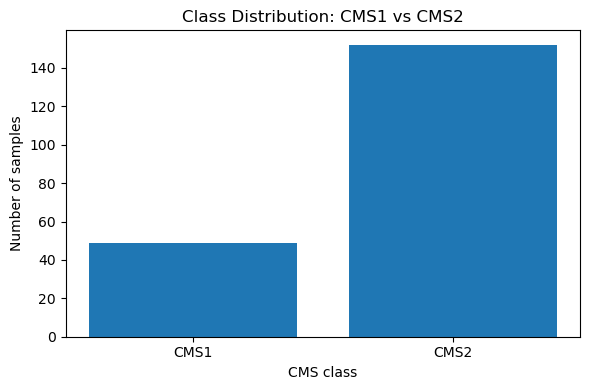

In [13]:
class_counts = binary_data["CMS"].value_counts().reindex(CMS_PAIR)

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title(f"Class Distribution: {POSITIVE_CLASS} vs {NEGATIVE_CLASS}")
plt.xlabel("CMS class")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "class_distribution_binary.png", dpi=300)
plt.show()

## 9. Define Features and Labels

Only gene expression columns are used as model input.  
Clinical metadata is not used in the baseline model to keep the first version simple and focused.

In [14]:
metadata_columns = ["submitter_id", "CMS", "target", "project_id", "pathologic_stage"]
gene_columns = [col for col in binary_data.columns if col not in metadata_columns]

X = binary_data[gene_columns].copy()
y = binary_data["target"].astype(int).copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Number of gene features:", len(gene_columns))

Feature matrix shape: (201, 56271)
Target vector shape: (201,)
Number of gene features: 56271


## 10. Train / Validation / Test Split

The data is split into:

- training set: used to fit the model
- validation set: used for model selection and early stopping
- test set: used only for final evaluation

Stratification keeps the class ratio similar in all splits.

In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print("Training set:", X_train.shape, y_train.value_counts().to_dict())
print("Validation set:", X_val.shape, y_val.value_counts().to_dict())
print("Test set:", X_test.shape, y_test.value_counts().to_dict())

Training set: (140, 56271) {0: 106, 1: 34}
Validation set: (30, 56271) {0: 23, 1: 7}
Test set: (31, 56271) {0: 23, 1: 8}


## 11. Feature Selection and Scaling

Gene expression data has many more features than samples.  
To reduce noise and overfitting, only the most informative genes are selected.

Important: feature selection and scaling are fitted only on the training data to avoid data leakage.

In [16]:
# Select top genes based on ANOVA F-score
k = min(N_SELECTED_GENES, X_train.shape[1])

feature_selector = SelectKBest(score_func=f_classif, k=k)
X_train_selected = feature_selector.fit_transform(X_train, y_train)
X_val_selected = feature_selector.transform(X_val)
X_test_selected = feature_selector.transform(X_test)

selected_gene_names = X_train.columns[feature_selector.get_support()].tolist()

# Scale selected features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_val_scaled = scaler.transform(X_val_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Selected number of genes:", len(selected_gene_names))
print("Processed training shape:", X_train_scaled.shape)

selected_genes_df = pd.DataFrame({"selected_gene": selected_gene_names})
selected_genes_df.to_csv(RESULTS_DIR / "selected_genes.csv", index=False)

display(selected_genes_df.head(10))

Selected number of genes: 500
Processed training shape: (140, 500)


,selected_gene
0,ENSG00000000003
1,ENSG00000002549
2,ENSG00000002933
3,ENSG00000005059
4,ENSG00000005700
5,ENSG00000006704
6,ENSG00000011422
7,ENSG00000018280
8,ENSG00000019582
9,ENSG00000021355


## 12. PCA Visualization

PCA is used only for visualization.  
It helps to inspect whether CMS1 and CMS2 samples show visible separation in a low-dimensional space.

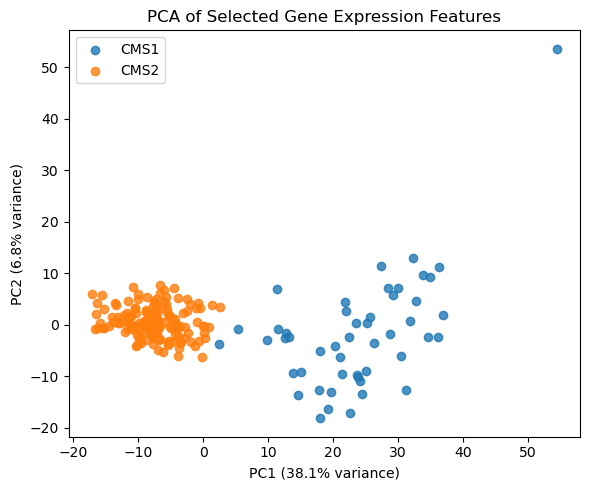

In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(np.vstack([X_train_scaled, X_val_scaled, X_test_scaled]))

plot_labels = pd.concat([y_train, y_val, y_test], axis=0).reset_index(drop=True)
plot_classes = plot_labels.map({1: POSITIVE_CLASS, 0: NEGATIVE_CLASS})

plt.figure(figsize=(6, 5))
for class_name in CMS_PAIR:
    mask = plot_classes == class_name
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=class_name,
        alpha=0.8,
    )

plt.title("PCA of Selected Gene Expression Features")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pca_binary_selected_genes.png", dpi=300)
plt.show()

## 13. Create PyTorch DataLoaders

PyTorch models work with tensors.  
The processed NumPy arrays are converted into tensors and loaded in mini-batches.

In [18]:
def make_dataloader(X_array, y_series, batch_size=16, shuffle=False):
    """Create a PyTorch DataLoader from feature and label arrays."""
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    y_tensor = torch.tensor(y_series.values, dtype=torch.float32).view(-1, 1)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_dataloader(X_train_scaled, y_train, BATCH_SIZE, shuffle=True)
val_loader = make_dataloader(X_val_scaled, y_val, BATCH_SIZE, shuffle=False)
test_loader = make_dataloader(X_test_scaled, y_test, BATCH_SIZE, shuffle=False)

## 14. Define the MLP Model

The model is a simple Feedforward Neural Network / Multi-Layer Perceptron.  
It receives selected gene expression values as input and returns one output value for binary classification.

In [19]:
class MLPClassifier(nn.Module):
    """Feedforward neural network for binary CMS classification."""

    def __init__(self, input_dim, hidden_dims=(128, 64), dropout=0.3):
        super().__init__()

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(previous_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

## 15. Training and Evaluation Functions

The functions below keep the notebook clean and make experiments easier to compare.

In [20]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train the model for one epoch and return the average loss."""
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(dataloader.dataset)


def evaluate_loss(model, dataloader, criterion, device):
    """Evaluate the model loss without updating weights."""
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(dataloader.dataset)


def predict_probabilities(model, dataloader, device):
    """Return predicted probabilities for the positive class."""
    model.eval()
    probabilities = []

    with torch.no_grad():
        for X_batch, _ in dataloader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            probabilities.extend(probs.cpu().numpy().ravel())

    return np.array(probabilities)

## 16. Train Baseline MLP with Early Stopping

Early stopping prevents the model from training too long after validation loss stops improving.

In [21]:
input_dim = X_train_scaled.shape[1]

model = MLPClassifier(
    input_dim=input_dim,
    hidden_dims=(128, 64),
    dropout=0.3,
).to(device)

# Handle possible class imbalance with pos_weight
n_positive = int(y_train.sum())
n_negative = int(len(y_train) - y_train.sum())
pos_weight_value = n_negative / max(n_positive, 1)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

history = {
    "train_loss": [],
    "val_loss": [],
}

best_val_loss = np.inf
best_model_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate_loss(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best validation loss: {best_val_loss:.4f}")
        break

model.load_state_dict(best_model_state)

Epoch 001 | train loss: 0.6576 | val loss: 0.2285
Epoch 010 | train loss: 0.0026 | val loss: 0.0042
Epoch 020 | train loss: 0.0007 | val loss: 0.0019
Epoch 030 | train loss: 0.0001 | val loss: 0.0012
Epoch 040 | train loss: 0.0001 | val loss: 0.0009
Epoch 050 | train loss: 0.0002 | val loss: 0.0007
Epoch 060 | train loss: 0.0001 | val loss: 0.0006
Epoch 070 | train loss: 0.0001 | val loss: 0.0005
Epoch 080 | train loss: 0.0001 | val loss: 0.0005
Epoch 090 | train loss: 0.0001 | val loss: 0.0004
Epoch 100 | train loss: 0.0001 | val loss: 0.0004


<All keys matched successfully>

## 17. Plot Training Curves

The training and validation loss curves help to identify overfitting.

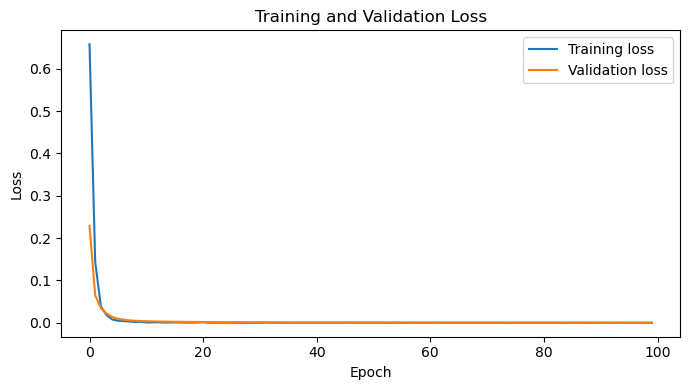

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Training loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_validation_loss.png", dpi=300)
plt.show()

## 18. Final Test Evaluation

The test set is used only at the end.  
This gives a more realistic estimate of how well the model generalizes to unseen samples.

In [23]:
test_probabilities = predict_probabilities(model, test_loader, device)
test_predictions = (test_probabilities >= 0.5).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, test_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_predictions),
    "precision": precision_score(y_test, test_predictions, zero_division=0),
    "recall": recall_score(y_test, test_predictions, zero_division=0),
    "f1": f1_score(y_test, test_predictions, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_probabilities),
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(RESULTS_DIR / "baseline_mlp_test_metrics.csv", index=False)

display(metrics_df)

print("Classification report:")
print(classification_report(
    y_test,
    test_predictions,
    target_names=[NEGATIVE_CLASS, POSITIVE_CLASS],
    zero_division=0,
))

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,1.0,1.0,1.0,1.0,1.0,1.0


Classification report:
              precision    recall  f1-score   support

        CMS2       1.00      1.00      1.00        23
        CMS1       1.00      1.00      1.00         8

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



## 19. Confusion Matrix

The confusion matrix shows which class is predicted correctly or incorrectly.

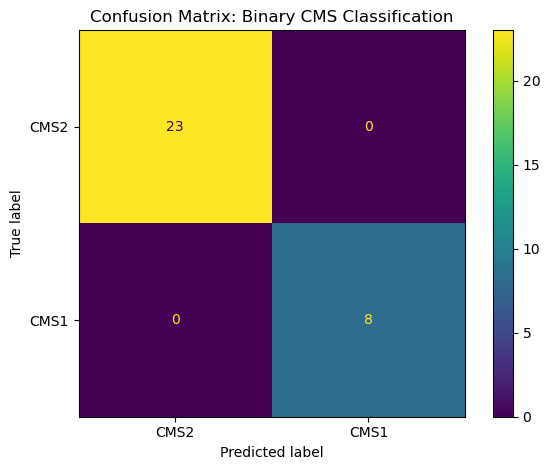

In [24]:
cm = confusion_matrix(y_test, test_predictions)

display_labels = [NEGATIVE_CLASS, POSITIVE_CLASS]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels,
)

disp.plot(values_format="d")
plt.title("Confusion Matrix: Binary CMS Classification")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrix_binary_mlp.png", dpi=300)
plt.show()

## 20. ROC Curve

The ROC curve evaluates how well the model separates the two classes across different thresholds.

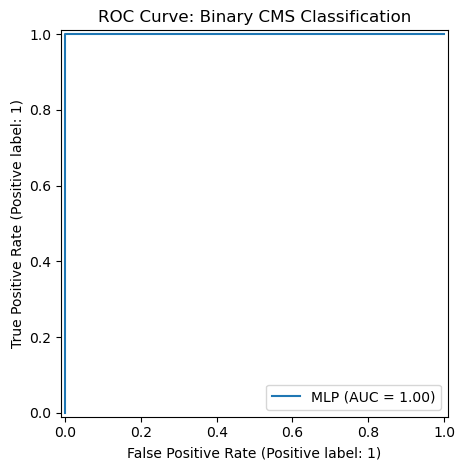

In [25]:
RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    name="MLP",
)

plt.title("ROC Curve: Binary CMS Classification")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "roc_curve_binary_mlp.png", dpi=300)
plt.show()

## 23. Save Final Model

The trained baseline model, selected genes, scaler, and feature selector are needed if the model should be reused later.

In [28]:
import pickle

torch.save(model.state_dict(), RESULTS_DIR / "baseline_mlp_model.pt")

with open(RESULTS_DIR / "preprocessing_objects.pkl", "wb") as file:
    pickle.dump(
        {
            "selected_gene_names": selected_gene_names,
            "feature_selector": feature_selector,
            "scaler": scaler,
            "positive_class": POSITIVE_CLASS,
            "negative_class": NEGATIVE_CLASS,
        },
        file,
    )

print("Model and preprocessing objects saved in:", RESULTS_DIR.resolve())

Model and preprocessing objects saved in: C:\Users\serna\OneDrive\Desktop\results


## 24. Discussion

The MLP model was used to classify colorectal cancer samples into two selected CMS subtypes based on gene expression data.

Important points for interpretation:

- The task was simplified to binary classification to reduce complexity.
- Gene expression data is high-dimensional, so feature selection was necessary.
- The number of samples is limited compared with the number of genes.
- Dropout, L2 regularization and early stopping were used to reduce overfitting.
- Accuracy alone is not sufficient; F1-score, recall, confusion matrix and ROC-AUC are more informative.
- The results should be interpreted carefully because external validation was not performed.

Possible future work:

- Compare the MLP with a Random Forest or logistic regression baseline.
- Test other CMS subtype pairs.
- Include clinical variables.
- Extend the project to multiclass CMS prediction only if enough time and data are available.

## 25. Conclusion

This notebook provides a clean binary deep learning workflow for CMS subtype prediction.

The final workflow includes:

1. Loading TCGA CRC gene expression and CMS subtype data  
2. Creating a binary CMS1 vs CMS2 classification task  
3. Performing train/validation/test splitting  
4. Selecting informative genes  
5. Training a PyTorch MLP model  
6. Evaluating the model with several metrics and figures  
7. Comparing simple model configurations  

This structure can be used directly as the basis for the deep learning project report and presentation.